# Étape 2 — Preprocessing & Préparation des Données

## Contexte
Suite à notre EDA, nous avons identifié les actions de preprocessing nécessaires.
Ce notebook prépare les données pour **deux tâches prédictives** :

- **Tâche 1 — Classification** : Prédire `churn` (0 = reste, 1 = part)
- **Tâche 2 — Régression (bonus)** : Prédire `revenue_at_risk = total_revenue × churn`

## Décisions issues de l'EDA
| Action | Justification EDA |
|--------|------------------|
| Supprimer `customer_id`, `city` | Pas de signal prédictif |
| Remplir `complaint_type` NaN → `No_Complaint` | 2045 NaN = clients sans plainte (logique métier) |
| Encoder les variables catégorielles | 12 colonnes object détectées |
| StandardScaler sur les numériques | Distributions étalées (nps_score: -100 à +100, total_revenue: 10-5900) |
| Split stratifié 80/20 | Déséquilibre 89.8% / 10.2% |
| `class_weight='balanced'` | Gérer le déséquilibre dans les modèles |
| Outliers conservés | Signaux business réels (payment_failures élevé = signal churn fort) |

---
## PARTIE 1 — Preprocessing commun (Classification & Régression)
---

## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Dossier de sortie pour sauvegarder les données preprocessées
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print(' Imports OK')

 Imports OK


## 2. Chargement des données

In [2]:
df = pd.read_csv('../data/customer_churn_business_dataset.csv')

print(f'Shape initial : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head(3)

Shape initial : (10000, 32)
Colonnes : ['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn']


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0


## 3. Nettoyage des données

### 3.1 Suppression des colonnes inutiles

D'après l'EDA, deux colonnes n'apportent aucun signal prédictif :
- `customer_id` : identifiant unique, ne se généralise pas
- `city` : trop granulaire (800+ valeurs uniques), redondant avec `country`

In [3]:
cols_to_drop = ['customer_id', 'city']
df = df.drop(columns=cols_to_drop)

print(f'Colonnes supprimées : {cols_to_drop}')
print(f'Shape après suppression : {df.shape}')

Colonnes supprimées : ['customer_id', 'city']
Shape après suppression : (10000, 30)


### 3.2 Traitement des valeurs manquantes

Seule `complaint_type` avait 2045 NaN dans notre EDA.
**Décision** : Remplacer par `'No_Complaint'` car l'absence de plainte est une information métier valide.

In [4]:
# Vérification avant
print('Valeurs manquantes AVANT :')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Remplacement
df['complaint_type'] = df['complaint_type'].fillna('No_Complaint')

# Vérification après
print('\nValeurs manquantes APRÈS :')
missing_after = df.isnull().sum().sum()
print(f'Total valeurs manquantes : {missing_after} ' if missing_after == 0 else f'⚠️ Il reste {missing_after} valeurs manquantes')

Valeurs manquantes AVANT :
complaint_type    2045
dtype: int64

Valeurs manquantes APRÈS :
Total valeurs manquantes : 0 


### 3.3 Vérification des types de données

On s'assure que chaque colonne a le bon type avant d'appliquer les transformations.
Les colonnes `object` devront être encodées, les colonnes numériques standardisées.

In [5]:
print('Types de données :')
print(df.dtypes.value_counts())
print('\nColonnes catégorielles (object) :')
cat_cols_all = df.select_dtypes(include='object').columns.tolist()
print(cat_cols_all)
print(f'\nNombre de colonnes catégorielles : {len(cat_cols_all)}')

Types de données :
int64      14
object     10
float64     6
Name: count, dtype: int64

Colonnes catégorielles (object) :
['gender', 'country', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']

Nombre de colonnes catégorielles : 10


## 4. Création des variables cibles

### Tâche 1 — Classification
Variable cible : `churn` (déjà présente dans le dataset, valeurs 0/1)

### Tâche 2 — Régression
Variable cible : `revenue_at_risk = total_revenue × churn`

- Si `churn == 1` → `revenue_at_risk = total_revenue` (le revenu entier est à risque)
- Si `churn == 0` → `revenue_at_risk = 0` (aucun risque confirmé)

D'après notre EDA : 1 021 clients churnent, représentant **862 640€** de revenu à risque.
La distribution est fortement asymétrique (skewness = 1.95) avec 89.8% de zéros — ce qui justifie l'usage de modèles robustes comme XGBoost ou Random Forest pour la régression.

In [6]:

# Tâche 1 : Variable cible classification

y_classif = df['churn'].copy()
print('Tâche 1 — Distribution churn :')
print(y_classif.value_counts())
print(f'Taux de churn : {y_classif.mean()*100:.1f}%')

# Tâche 2 : Variable cible régression
# revenue_at_risk = total_revenue * churn
# (clients churnés : 100% de leur revenu est à risque)
# (clients non-churnés : 0 à risque confirmé)

df['revenue_at_risk'] = df['total_revenue'] * df['churn']
y_regress = df['revenue_at_risk'].copy()

print('\nTâche 2 — Revenue at risk (€) :')
print(y_regress.describe())
print(f'\nRevenu total à risque : {y_regress.sum():,.0f} €')
print(f'Revenu moyen à risque par client churné : {y_regress[y_regress>0].mean():,.0f} €')

Tâche 1 — Distribution churn :
churn
0    8979
1    1021
Name: count, dtype: int64
Taux de churn : 10.2%

Tâche 2 — Revenue at risk (€) :
count    10000.000000
mean        86.264000
std        404.207175
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       5500.000000
Name: revenue_at_risk, dtype: float64

Revenu total à risque : 862,640 €
Revenu moyen à risque par client churné : 845 €


## 5. Préparation des features

### 5.1 Identification des colonnes par type

On sépare les features en deux groupes pour appliquer 
les bonnes transformations à chaque type.

Note : `total_revenue` est exclue des features car elle sert 
à construire la variable cible `revenue_at_risk`. La garder 
introduirait un data leakage direct.

- **28 features** au total (après exclusion de `churn`, 
  `revenue_at_risk` et `total_revenue`)
- **18 variables numériques** → StandardScaler
- **10 variables catégorielles** → OneHotEncoder

In [7]:
# On retire les colonnes cibles du dataset features
cols_to_exclude = ['churn', 'revenue_at_risk', 'total_revenue']
X = df.drop(columns=cols_to_exclude)

# Colonnes numériques
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Colonnes catégorielles
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print(f'Features totales : {X.shape[1]}')
print(f'\nColonnes numériques ({len(numerical_cols)}) :')
print(numerical_cols)
print(f'\nColonnes catégorielles ({len(categorical_cols)}) :')
print(categorical_cols)

Features totales : 28

Colonnes numériques (18) :
['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count']

Colonnes catégorielles (10) :
['gender', 'country', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']


### 5.2 Vérification des cardinalités des variables catégorielles

Important pour choisir la stratégie d'encodage :
- Faible cardinalité (< 10 modalités) → OneHotEncoding
- Haute cardinalité → OrdinalEncoding ou Target Encoding

Résultats :
- Toutes les variables ont entre **2 et 7 modalités**
- OneHotEncoding est donc adapté pour toutes
- Les 10 variables catégorielles génèreront **32 colonnes** après OHE :
  gender(2) + country(7) + segment(3) + channel(3) + contract(3)
  + payment(3) + discount(2) + price_increase(2) + complaint(4) + survey(3) = 32

Total features après encoding : **18 numériques + 32 OHE = 50 features**

In [8]:
print('Cardinalité des variables catégorielles :')
for col in categorical_cols:
    n = X[col].nunique()
    vals = X[col].unique()
    print(f'  {col} : {n} valeurs → {list(vals)}')

Cardinalité des variables catégorielles :
  gender : 2 valeurs → ['Male', 'Female']
  country : 7 valeurs → ['Bangladesh', 'Canada', 'Germany', 'Australia', 'India', 'USA', 'UK']
  customer_segment : 3 valeurs → ['SME', 'Individual', 'Enterprise']
  signup_channel : 3 valeurs → ['Web', 'Mobile', 'Referral']
  contract_type : 3 valeurs → ['Monthly', 'Yearly', 'Quarterly']
  payment_method : 3 valeurs → ['PayPal', 'Card', 'Bank Transfer']
  discount_applied : 2 valeurs → ['Yes', 'No']
  price_increase_last_3m : 2 valeurs → ['No', 'Yes']
  complaint_type : 4 valeurs → ['Service', 'Billing', 'Technical', 'No_Complaint']
  survey_response : 3 valeurs → ['Satisfied', 'Neutral', 'Unsatisfied']


## 6. Split Train / Test

**Stratégie** : Split stratifié 80% / 20% sur `churn` pour respecter le ratio 89.8/10.2%

**Important** : Le split se fait AVANT le preprocessing pour éviter le data leakage.
Le scaler sera fitté uniquement sur le train set.

In [9]:

# Split pour Tâche 1 — Classification

X_train_raw, X_test_raw, y_train_clf, y_test_clf = train_test_split(
    X, y_classif,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_classif  # Stratifié car déséquilibre 90/10
)

# Split pour Tâche 2 — Régression (mêmes indices)

y_train_reg = y_regress.loc[X_train_raw.index]
y_test_reg  = y_regress.loc[X_test_raw.index]

print('Splits effectués')
print(f'Train : {X_train_raw.shape[0]} lignes')
print(f'Test  : {X_test_raw.shape[0]} lignes')
print(f'\nDistribution churn — Train : {y_train_clf.mean()*100:.1f}% churners')
print(f'Distribution churn — Test  : {y_test_clf.mean()*100:.1f}% churners')

Splits effectués
Train : 8000 lignes
Test  : 2000 lignes

Distribution churn — Train : 10.2% churners
Distribution churn — Test  : 10.2% churners


## 7. Construction du Pipeline de Preprocessing

On utilise `ColumnTransformer` + `Pipeline` de scikit-learn pour :
1. **Éviter le data leakage** : fit sur train uniquement
2. **Reproductibilité** : même transformation sur train et test
3. **Intégration future dans le dashboard** : pipeline sérialisable avec joblib

**Stratégie d'encodage** :
- Colonnes numériques (18) → `StandardScaler` : centre et réduit 
  chaque variable (moyenne = 0, écart-type = 1). Indispensable 
  pour la Régression Logistique et le MLP.
- Colonnes catégorielles (10) → `OneHotEncoder` : transforme 
  chaque modalité en colonne binaire (0/1). Adapté car toutes 
  les variables ont une faible cardinalité (2 à 7 modalités).

Le `ColumnTransformer` applique chaque transformation aux bonnes 
colonnes en parallèle, puis concatène le résultat en une seule 
matrice de **50 features**.

In [ ]:

# Pipeline numérique

numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
# Pipeline catégoriel

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',   # Gère les valeurs inconnues en test
        sparse_output=False        # Retourne une matrice dense
    ))
])

# ColumnTransformer : applique chaque pipeline aux bonnes colonnes

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'  # Supprime les colonnes non mentionnées
)

print('Pipeline de preprocessing défini')
print(f'  Colonnes numériques ({len(numerical_cols)}) → StandardScaler')
print(f'  Colonnes catégorielles ({len(categorical_cols)}) → OneHotEncoder')

Pipeline de preprocessing défini
  Colonnes numériques (18) → StandardScaler
  Colonnes catégorielles (10) → OneHotEncoder


## 8. Application du Pipeline

**Règle d'or anti data-leakage** :
- `fit_transform()` sur le **train** uniquement
- `transform()` sur le **test** (utilise les paramètres appris sur le train)

In [11]:
# Fit sur TRAIN uniquement + transform
X_train = preprocessor.fit_transform(X_train_raw)

# Transform sur TEST (pas de fit !)
X_test = preprocessor.transform(X_test_raw)

print(' Preprocessing appliqué')
print(f'X_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')

# Récupération des noms de colonnes après OneHotEncoding
ohe_cols = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(ohe_cols)
print(f'\nNombre total de features après encoding : {len(all_feature_names)}')

 Preprocessing appliqué
X_train shape : (8000, 50)
X_test shape  : (2000, 50)

Nombre total de features après encoding : 50


## 9. Vérifications post-preprocessing

On vérifie que le pipeline a bien fonctionné :
- **Valeurs manquantes** : doit être 0 (on a déjà traité `complaint_type`)
- **Centrage** : moyenne ≈ 0 sur les colonnes numériques après StandardScaler
- **Réduction** : écart-type ≈ 1 sur les colonnes numériques après StandardScaler

In [12]:
# Conversion en DataFrame pour inspection
X_train_df = pd.DataFrame(X_train, columns=all_feature_names)
X_test_df  = pd.DataFrame(X_test,  columns=all_feature_names)

print('=== Vérification Train ===')
print(f'Shape : {X_train_df.shape}')
print(f'Valeurs manquantes : {X_train_df.isnull().sum().sum()}')
print(f'Moyenne colonne age (doit être ≈0 après scaling) : {X_train_df["age"].mean():.4f}')
print(f'Std colonne age (doit être ≈1 après scaling) : {X_train_df["age"].std():.4f}')

print('\n=== Vérification Test ===')
print(f'Shape : {X_test_df.shape}')
print(f'Valeurs manquantes : {X_test_df.isnull().sum().sum()}')

print('\nLes données sont prêtes pour la modélisation')

=== Vérification Train ===
Shape : (8000, 50)
Valeurs manquantes : 0
Moyenne colonne age (doit être ≈0 après scaling) : 0.0000
Std colonne age (doit être ≈1 après scaling) : 1.0001

=== Vérification Test ===
Shape : (2000, 50)
Valeurs manquantes : 0

Les données sont prêtes pour la modélisation


In [13]:
# Aperçu des premières colonnes
X_train_df.head(3)

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,payment_failures,...,discount_applied_Yes,price_increase_last_3m_No,price_increase_last_3m_Yes,complaint_type_Billing,complaint_type_No_Complaint,complaint_type_Service,complaint_type_Technical,survey_response_Neutral,survey_response_Satisfied,survey_response_Unsatisfied
0,-0.240659,-0.423840,0.027367,1.087419,-1.980728,-0.454115,-1.000280,1.992799,-1.044507,-0.706409,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.405500,-0.716027,0.843546,1.087419,-0.677429,-0.003381,-0.866760,-0.152316,-0.204871,0.702534,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-1.155192,-1.358840,0.027367,1.087419,-1.011074,-0.454115,0.868996,-0.254464,1.474400,0.702534,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 10. Visualisation post-preprocessing

Vérification visuelle que le scaling a bien fonctionné sur 
quelques variables clés.

Chaque distribution est maintenant centrée autour de 0 (ligne 
rouge pointillée) avec un écart-type de 1, confirmé par les 
titres (μ=0.00, σ=1.00).

Note : les formes des distributions sont **conservées** — 
StandardScaler ne normalise pas la forme, il change uniquement 
l'échelle. C'est pourquoi `payment_failures` reste très 
asymétrique et `monthly_fee` reste en paliers discrets.

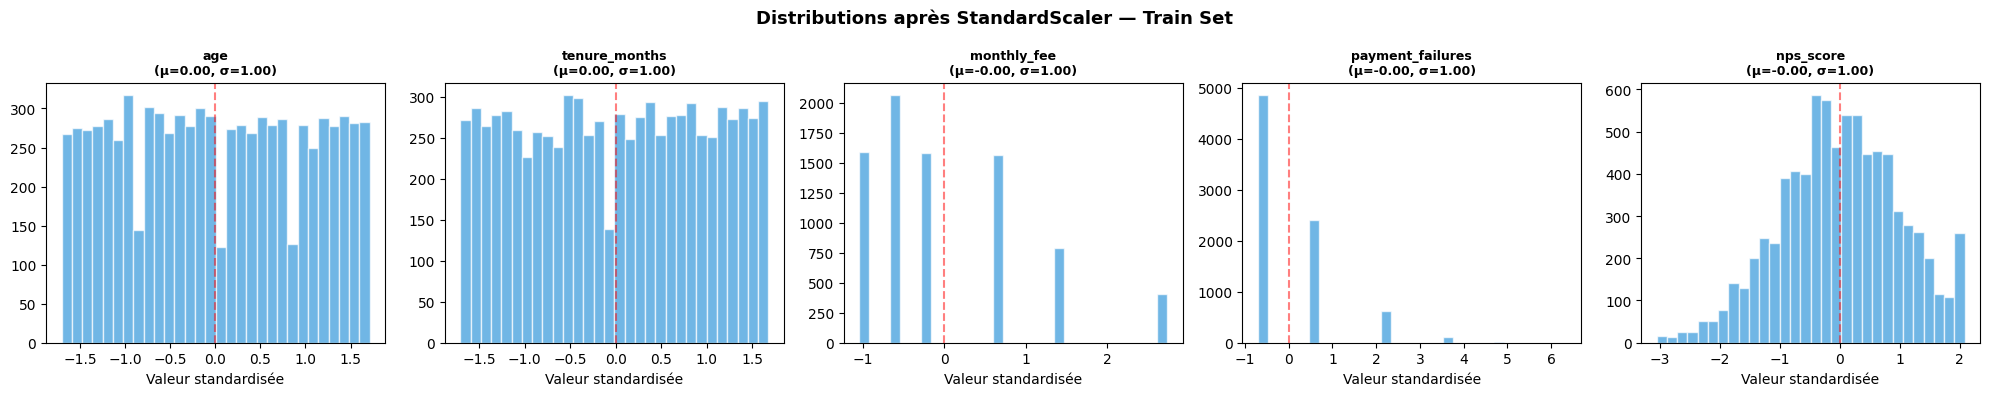

In [14]:
# Variables numériques importantes à vérifier
vars_to_check = ['age', 'tenure_months', 'monthly_fee', 'payment_failures', 'nps_score']

fig, axes = plt.subplots(1, len(vars_to_check), figsize=(20, 4))

for i, col in enumerate(vars_to_check):
    axes[i].hist(X_train_df[col], bins=30, color='#3498db', alpha=0.7, edgecolor='white')
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5, label='μ=0')
    axes[i].set_title(f'{col}\n(μ={X_train_df[col].mean():.2f}, σ={X_train_df[col].std():.2f})',
                      fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Valeur standardisée')

plt.suptitle('Distributions après StandardScaler — Train Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## PARTIE 2 — Preprocessing spécifique à la Classification


## 11. Gestion du déséquilibre — Comparaison de deux techniques

L'EDA a révélé un déséquilibre fort : **89.8% non-churners vs 10.2% churners**.

Sans correction, un modèle naïf qui prédit toujours "reste" aurait 89.8% d'accuracy sans rien apprendre.

On compare ici **deux techniques de rééquilibrage** :

### Technique 1 — `RandomUnderSampler`
- Réduit la classe majoritaire (non-churners) → ratio 50/50
- **Avantage** : simple, rapide, pas de données synthétiques
- **Inconvénient** : perte d'information (~7 000 exemples supprimés)

### Technique 2 — `SMOTE` (Synthetic Minority Over-sampling Technique)
- Crée de nouveaux exemples **synthétiques** de churners par interpolation entre voisins proches
- **Avantage** : conserve toutes les données originales, enrichit la classe minoritaire
- **Inconvénient** : peut introduire du bruit, dataset plus grand → entraînement plus lent

Les deux datasets sont sauvegardés pour être **comparés dans le notebook de modélisation**.

## 11. Gestion du Déséquilibre — RandomUnderSampler & SMOTE

Le dataset est fortement déséquilibré : 
**89.8% non-churners vs 10.2% churners**.

On compare **trois stratégies** appliquées sur `X_train` 
uniquement — `X_test` reste intact pour l'évaluation réaliste :

- **RandomUnderSampler** : réduit la classe majoritaire → 
  1 634 samples (817 + 817)
- **SMOTE** : génère des churners synthétiques → 
  10 400 samples (5 200 + 5 200)
- **class_weight='balanced'** : pondération au niveau du modèle,
  sans modifier les données → 7 183 + 817 samples inchangés

Pour chaque modèle, la stratégie offrant le meilleur Recall 
sera retenue.

Distribution AVANT rééchantillonnage :

  Reste  (0)  :  7183 (89.8%)
  Churne (1)  :   817 (10.2%)

--- Technique 1 : RandomUnderSampler ---
  Reste  (0)  :   817 (50.0%)
  Churne (1)  :   817 (50.0%)
  Samples supprimés : 6366

--- Technique 2 : SMOTE ---
  Reste  (0)  :  5200 (50.0%)
  Churne (1)  :  5200 (50.0%)
  Exemples synthétiques créés : 4383



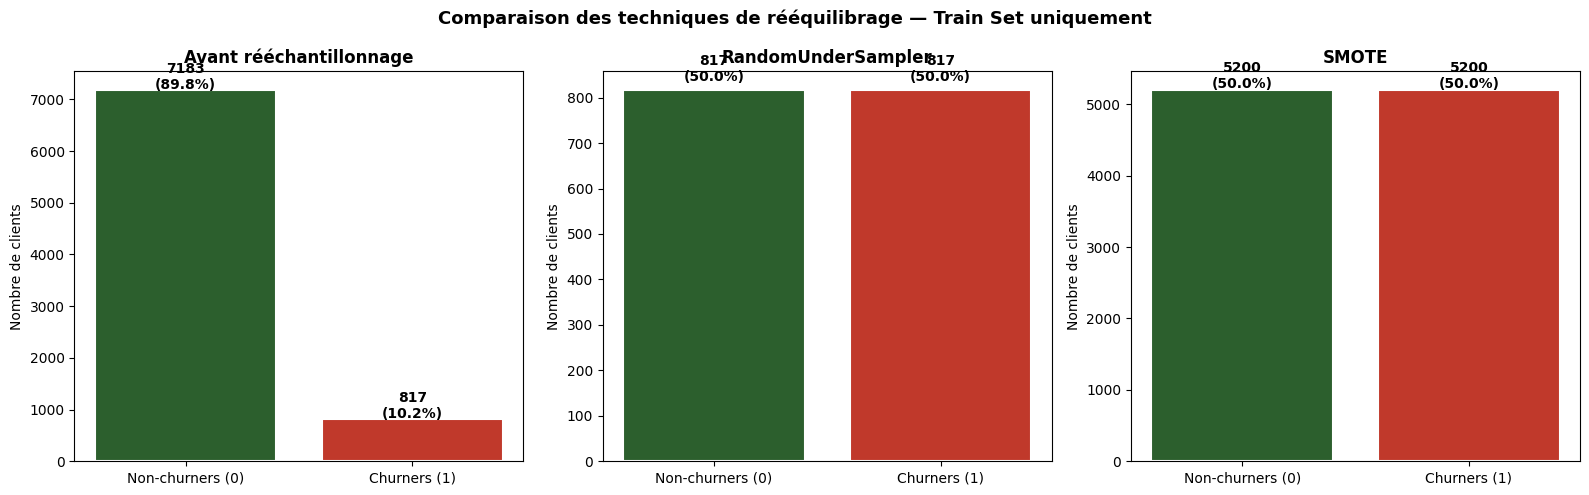

[OK] UnderSampler et SMOTE appliqués. X_test inchangé.


In [15]:
# ============================================================
# GESTION DU DÉSÉQUILIBRE — UNDERSAMPLING + SMOTE
# ============================================================

n0_before = int(np.sum(y_train_clf == 0))
n1_before = int(np.sum(y_train_clf == 1))
total_before = n0_before + n1_before

print('Distribution AVANT rééchantillonnage :')
print()
print(f'  Reste  (0)  : {n0_before:>5} ({n0_before/total_before*100:.1f}%)')
print(f'  Churne (1)  : {n1_before:>5} ({n1_before/total_before*100:.1f}%)')
print()

# ---- TECHNIQUE 1 : RandomUnderSampler ----
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_under, y_train_clf_under = rus.fit_resample(X_train, y_train_clf)

n0_under = int(np.sum(y_train_clf_under == 0))
n1_under = int(np.sum(y_train_clf_under == 1))
total_under = n0_under + n1_under

print('--- Technique 1 : RandomUnderSampler ---')
print(f'  Reste  (0)  : {n0_under:>5} ({n0_under/total_under*100:.1f}%)')
print(f'  Churne (1)  : {n1_under:>5} ({n1_under/total_under*100:.1f}%)')
print(f'  Samples supprimés : {total_before - total_under}')
print()

# ---- TECHNIQUE 2 : SMOTE (avec réduction préalable de 2000 non-churners) ----
idx_non_churn = np.where(y_train_clf == 0)[0]
idx_drop = np.random.choice(idx_non_churn, size=len(idx_non_churn)-5200, replace=False)
X_train_pre = np.delete(X_train, idx_drop, axis=0)
y_train_pre = np.delete(y_train_clf, idx_drop, axis=0)

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_clf_smote = smote.fit_resample(X_train_pre, y_train_pre)

n0_smote = int(np.sum(y_train_clf_smote == 0))
n1_smote = int(np.sum(y_train_clf_smote == 1))
total_smote = n0_smote + n1_smote
n_synth = n1_smote - n1_before

print('--- Technique 2 : SMOTE ---')
print(f'  Reste  (0)  : {n0_smote:>5} ({n0_smote/total_smote*100:.1f}%)')
print(f'  Churne (1)  : {n1_smote:>5} ({n1_smote/total_smote*100:.1f}%)')
print(f'  Exemples synthétiques créés : {n_synth}')
print()

# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configs = [
    ('Avant rééchantillonnage', n0_before, n1_before),
    ('RandomUnderSampler', n0_under, n1_under),
    ('SMOTE', n0_smote, n1_smote),
]

for ax, (title, n0, n1) in zip(axes, configs):
    total = n0 + n1
    ax.bar(['Non-churners (0)', 'Churners (1)'], [n0, n1],
           color=['#2C5F2D', '#C0392B'], edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Nombre de clients')
    for i, v in enumerate([n0, n1]):
        ax.text(i, v + 20, f'{v}\n({v/total*100:.1f}%)',
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Comparaison des techniques de rééquilibrage — Train Set uniquement',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('[OK] UnderSampler et SMOTE appliqués. X_test inchangé.')

## 12. Préparation des données pour la Régression

L'EDA a révélé deux caractéristiques clés de `revenue_at_risk` 
qui imposent un traitement spécifique :

**1. Masse de zéros (89.8%)** : 8 979 clients ont 
`revenue_at_risk = 0` car ils ne churnent pas.
Entraîner le modèle de régression sur tous les clients biaiserait 
fortement les prédictions vers 0.
→ **On entraîne uniquement sur les 817 churners du train set**.

**2. Distribution asymétrique (skewness = 1.95)** : les valeurs 
vont de 10€ à 5 500€ avec une forte concentration sur les petits 
montants.
→ **On applique `np.log1p()`** sur `y_train_reg` pour stabiliser 
la distribution. La transformation inverse `np.expm1()` sera 
appliquée lors des prédictions finales.

**3. Pas d'undersampling** : contrairement à la classification, 
on garde tous les churners. L'undersampling ne s'applique pas ici.

Note : la moyenne ici (860€) diffère légèrement de celle du 
dataset complet (845€) car on travaille uniquement sur le 
train set (817 churners sur 1 021 au total).

In [16]:
# ============================================================
# PARTIE RÉGRESSION — Filtrage sur les churners uniquement
# ============================================================

# Masque booléen des churners dans le train
churners_mask_train = y_train_clf.values == 1

# X et y pour la régression — uniquement les churners
X_train_reg = X_train[churners_mask_train]
y_train_reg_churners = y_train_reg.loc[X_train_raw.index][churners_mask_train]

print("Données régression — Train (churners uniquement) :")
print(f"  Avant filtrage : {X_train.shape[0]} lignes")
print(f"  Après filtrage : {X_train_reg.shape[0]} lignes (churners uniquement)")
print(f"  Revenue at risk — min    : {y_train_reg_churners.min():.0f}€")
print(f"  Revenue at risk — max    : {y_train_reg_churners.max():.0f}€")
print(f"  Revenue at risk — moyenne : {y_train_reg_churners.mean():.0f}€")
print(f"  Revenue at risk — médiane : {y_train_reg_churners.median():.0f}€")

Données régression — Train (churners uniquement) :
  Avant filtrage : 8000 lignes
  Après filtrage : 817 lignes (churners uniquement)
  Revenue at risk — min    : 10€
  Revenue at risk — max    : 5500€
  Revenue at risk — moyenne : 860€
  Revenue at risk — médiane : 490€


## 13. Log-transformation de `revenue_at_risk`

La distribution de `revenue_at_risk` sur les churners du train 
set présente une **skewness de 1.91** — fortement asymétrique.

Les modèles de régression (notamment Ridge et MLP) sont sensibles 
à cette asymétrie car :
- Ils optimisent le MSE (Mean Squared Error)
- Les grandes valeurs dominent la loss et biaisent les prédictions

**Solution : `np.log1p()`**
- `log1p(x) = log(1 + x)` → gère les valeurs proches de 0 
  sans erreur
- Compresse les grandes valeurs (ex: 5 500€ → 8.6) et étale 
  les petites
- La transformation inverse `np.expm1()` sera appliquée lors 
  des prédictions finales pour retrouver les euros réels

Résultat : skewness passe de **1.91 → -0.41** → distribution 
beaucoup plus symétrique et adaptée à la régression.

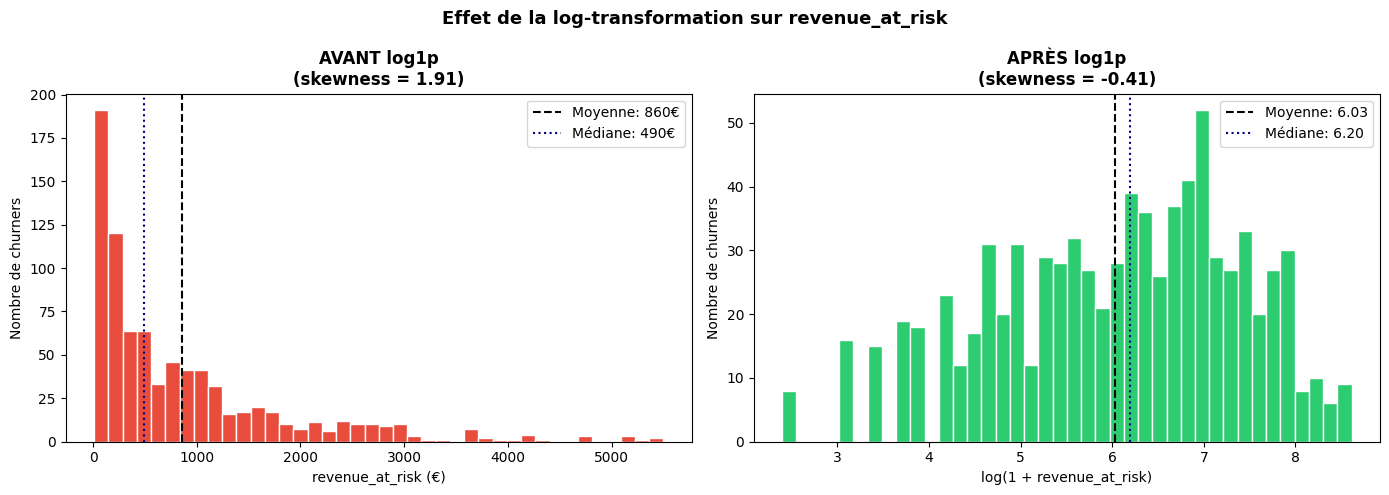

Skewness AVANT : 1.91
Skewness APRÈS : -0.41
→ Distribution beaucoup plus symétrique, meilleure pour la régression


In [17]:
# ============================================================
# LOG-TRANSFORMATION sur y_train_reg
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

y_train_reg_log = np.log1p(y_train_reg_churners)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avant transformation
axes[0].hist(y_train_reg_churners, bins=40, color='#e74c3c', edgecolor='white')
axes[0].set_title(f'AVANT log1p\n(skewness = {y_train_reg_churners.skew():.2f})',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('revenue_at_risk (€)')
axes[0].set_ylabel('Nombre de churners')
axes[0].axvline(y_train_reg_churners.mean(), color='black', linestyle='--',
                label=f'Moyenne: {y_train_reg_churners.mean():.0f}€')
axes[0].axvline(y_train_reg_churners.median(), color='navy', linestyle=':',
                label=f'Médiane: {y_train_reg_churners.median():.0f}€')
axes[0].legend()

# Après transformation
axes[1].hist(y_train_reg_log, bins=40, color='#2ecc71', edgecolor='white')
axes[1].set_title(f'APRÈS log1p\n(skewness = {y_train_reg_log.skew():.2f})',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(1 + revenue_at_risk)')
axes[1].set_ylabel('Nombre de churners')
axes[1].axvline(y_train_reg_log.mean(), color='black', linestyle='--',
                label=f'Moyenne: {y_train_reg_log.mean():.2f}')
axes[1].axvline(y_train_reg_log.median(), color='navy', linestyle=':',
                label=f'Médiane: {y_train_reg_log.median():.2f}')
axes[1].legend()

plt.suptitle('Effet de la log-transformation sur revenue_at_risk',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness AVANT : {y_train_reg_churners.skew():.2f}")
print(f"Skewness APRÈS : {y_train_reg_log.skew():.2f}")
print("→ Distribution beaucoup plus symétrique, meilleure pour la régression")

## 14. Sauvegarde de toutes les données preprocessées

On sauvegarde séparément les données pour la classification 
et la régression :

**Classification** :
- `X_train.npy` (8000, 50) — données originales
- `X_train_under.npy` (1634, 50) — après RandomUnderSampler
- `X_train_smote.npy` (10400, 50) — après SMOTE
- `X_test.npy` (2000, 50) — jeu de test (jamais modifié)
- `y_train_clf.npy` / `y_test_clf.npy`

**Régression** :
- `X_train_reg.npy` (817, 50) — churners uniquement
- `y_train_reg_log.npy` (817,) — valeurs log-transformées 
  (entrée du modèle)
- `y_train_reg_raw.npy` (817,) — valeurs réelles en € 
  (référence)
- `y_test_reg.npy` (2000,)

**Pipeline** :
- `preprocessor.pkl` — réutilisé à l'identique dans le 
  dashboard et l'API
- `feature_names.csv` — liste des 50 features

In [18]:
# ============================================================
# SAUVEGARDE
# ============================================================

import joblib
import os

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Pipeline preprocessor
joblib.dump(preprocessor, '../models/preprocessor.pkl')

# --- CLASSIFICATION ---
np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/X_train_under.npy', X_train_under)
np.save('../data/processed/y_train_clf_under.npy', y_train_clf_under)
np.save('../data/processed/X_train_smote.npy', X_train_smote)
np.save('../data/processed/y_train_clf_smote.npy', y_train_clf_smote)
np.save('../data/processed/X_test.npy', X_test)
np.save('../data/processed/y_train_clf.npy', y_train_clf.values)
np.save('../data/processed/y_test_clf.npy', y_test_clf.values)

# --- RÉGRESSION ---
np.save('../data/processed/X_train_reg.npy', X_train_reg)
np.save('../data/processed/y_train_reg_log.npy', y_train_reg_log.values)
np.save('../data/processed/y_train_reg_raw.npy', y_train_reg_churners.values)
np.save('../data/processed/y_test_reg.npy', y_test_reg.values)

# Noms des features
pd.Series(all_feature_names).to_csv('../data/processed/feature_names.csv', index=False)

print('Sauvegarde terminée')
print()
print('--- CLASSIFICATION ---')
print(f'  X_train.npy          : {X_train.shape}')
print(f'  X_train_under.npy    : {X_train_under.shape}')
print(f'  X_train_smote.npy    : {X_train_smote.shape}')
print(f'  X_test.npy           : {X_test.shape}')
print(f'  y_train_clf.npy      : {y_train_clf.shape}')
print(f'  y_test_clf.npy       : {y_test_clf.shape}')
print()
print('--- RÉGRESSION ---')
print(f'  X_train_reg.npy      : {X_train_reg.shape}  (churners uniquement)')
print(f'  y_train_reg_log.npy  : {y_train_reg_log.shape}  (log-transformé)')
print(f'  y_train_reg_raw.npy  : {y_train_reg_churners.shape}  (valeurs réelles €)')
print(f'  y_test_reg.npy       : {y_test_reg.shape}')
print()
print(f'  feature_names.csv    : {len(all_feature_names)} features')

Sauvegarde terminée

--- CLASSIFICATION ---
  X_train.npy          : (8000, 50)
  X_train_under.npy    : (1634, 50)
  X_train_smote.npy    : (10400, 50)
  X_test.npy           : (2000, 50)
  y_train_clf.npy      : (8000,)
  y_test_clf.npy       : (2000,)

--- RÉGRESSION ---
  X_train_reg.npy      : (817, 50)  (churners uniquement)
  y_train_reg_log.npy  : (817,)  (log-transformé)
  y_train_reg_raw.npy  : (817,)  (valeurs réelles €)
  y_test_reg.npy       : (2000,)

  feature_names.csv    : 50 features


## 15. Synthèse du Preprocessing

| Étape | Action | Tâche | Justification |
|-------|--------|-------|---------------|
| Suppression colonnes | `customer_id`, `city` | Les deux | Pas de signal prédictif |
| Valeurs manquantes | `complaint_type` NaN → `No_Complaint` | Les deux | 2045 clients sans plainte (logique métier) |
| Variable cible 1 | `churn` (déjà présente) | Classification | Binaire 0/1 |
| Variable cible 2 | `revenue_at_risk = total_revenue × churn` | Régression | Impact financier (862 640€ à risque) |
| Split | 80% train / 20% test, stratifié | Les deux | Préserve le ratio 89.8/10.2% |
| Encoding | OneHotEncoding sur 10 colonnes catégorielles | Les deux | Toutes à faible cardinalité (2-7 modalités) → 32 colonnes OHE |
| Log-transformation | `np.log1p()` sur `y_train_reg` | Régression uniquement | Skewness 1.91 → distribution plus symétrique |
| Scaling | StandardScaler sur colonnes numériques | Les deux | Indispensable pour LR et MLP |
| Anti-leakage | fit uniquement sur train | Les deux | Évite la contamination du test |
| Under-Sampling | RandomUnderSampler → 50/50 sur train | Classification uniquement | Supprime exemples majoritaires |
| SMOTE | Génération synthétique → 50/50 sur train | Classification uniquement | Interpole entre churners existants |
| Filtrage churners | `X_train_reg` = churners uniquement | Régression uniquement | 89.8% de zéros biaiseraient le modèle |
| Outliers | Conservés | Les deux | Signaux business réels (ex: payment_failures élevé) |

## Étape suivante
**Notebook 03 — Modélisation Classification** :
- Logistic Regression (baseline)
- Random Forest
- XGBoost / Gradient Boosting
- MLP (Deep Learning)
- Comparaison + Feature Importance + SHAP

**Notebook 04 — Modélisation Régression** :
- Ridge Regression (baseline)
- Random Forest Regressor
- XGBoost Regressor
- Évaluation sur les euros réels (après `np.expm1()`)

## 16. Vérification Anti-Data Leakage

Contrôle final pour garantir l'intégrité méthodologique du pipeline :

- **Train/Test disjoint** : aucun client commun entre les deux jeux
- **StandardScaler fit on train only** : moyenne ≈ 0 sur le train 
  confirme que le scaler n'a pas vu le test
- **Stratification correct** : ratio churners identique dans 
  train et test (10.2%)
- **OneHotEncoder handle_unknown='ignore'** : les valeurs 
  inconnues en production ne feront pas planter le pipeline

In [19]:
# DATA LEAKAGE VERIFICATION

print("\n" + "="*80)
print("DATA LEAKAGE CHECK")
print("="*80)

checks = [
    ("Train/Test disjoint", len(set(X_train_raw.index) & set(X_test_raw.index)) == 0),
    ("StandardScaler fit on train only", abs(X_train_df['age'].mean()) < 0.01),
    ("Stratification correct", abs(y_train_clf.mean() - y_test_clf.mean()) < 0.01),
    ("OneHotEncoder handle_unknown", preprocessor.named_transformers_['cat']['onehot'].handle_unknown == 'ignore'),
]

all_pass = all(result for _, result in checks)
for name, result in checks:
    print(f"{'GOOD' if result else 'ERROR'} {name}")

print(f"\n{'GOOD NO DATA LEAKAGE DETECTED!' if all_pass else 'ERROR DATA LEAKAGE DETECTED!'}")
print("="*80)


DATA LEAKAGE CHECK
GOOD Train/Test disjoint
GOOD StandardScaler fit on train only
GOOD Stratification correct
GOOD OneHotEncoder handle_unknown

GOOD NO DATA LEAKAGE DETECTED!
